In [9]:
import pandas as pd 
import pickle
import numpy as np
# AU DATA
stroke_df = pd.read_csv("/Users/beatrizrebelo/Desktop/Tese-MECD/Datasets/stroke_final.csv")
hc_df     = pd.read_csv("/Users/beatrizrebelo/Desktop/Tese-MECD/Datasets/hc_final.csv")
df = pd.concat([stroke_df, hc_df], ignore_index=True)

# EMBEDDINGS
with open("/Users/beatrizrebelo/Desktop/TESE/ResMaskNet1/embeddings_and_predictions.pkl", "rb") as f:
    emb_data = pickle.load(f)

def clean_key(k):

    k = k.replace("healthy/", "").replace("stroke/", "")

    k = k.replace("_color", "")

    return k

emb_data = {clean_key(k): v for k, v in emb_data.items()}

# BUILD VIDEO INFO

df["video"] = df["participant_id"].astype(str) + "_" + df["task"].astype(str)

video_to_task = {}

video_to_label = {}

video_to_len = {}

video_to_emb = {}

for v in df["video"].unique():

    sub = df[df["video"] == v]

    if v not in emb_data:

        continue

    emb = np.array(emb_data[v]["embeddings"])

    video_to_task[v] = sub["task"].iloc[0]

    video_to_label[v] = sub["label"].iloc[0]

    video_to_len[v] = len(emb)

    video_to_emb[v] = emb

In [10]:
import pandas as pd

rows = []

for v in video_to_emb:
    rows.append({
        "task": video_to_task[v],
        "length": video_to_len[v]
    })

df_len = pd.DataFrame(rows)

print("\n=== LENGTH STATS PER TASK ===")
print(df_len.groupby("task")["length"].describe())


=== LENGTH STATS PER TASK ===
            count         mean         std    min     25%     50%      75%  \
task                                                                         
BBP_NORMAL   25.0  1673.600000  785.567947  639.0  1118.0  1512.0  1949.00   
DDK_PA       25.0   984.240000  534.311495  384.0   660.0   888.0  1150.00   
DDK_PATAKA   25.0   874.160000  408.875865  368.0   553.0   695.0  1286.00   
NSM_BLOW     18.0   581.555556  200.789976  287.0   447.0   585.5   704.25   
NSM_KISS     25.0   548.280000  277.513291  247.0   358.0   424.0   682.00   
NSM_OPEN     25.0   577.560000  208.591922  343.0   420.0   560.0   673.00   
NSM_SPREAD   25.0   678.760000  341.701658  342.0   410.0   501.0   857.00   

               max  
task                
BBP_NORMAL  4127.0  
DDK_PA      2964.0  
DDK_PATAKA  1589.0  
NSM_BLOW    1003.0  
NSM_KISS    1253.0  
NSM_OPEN    1341.0  
NSM_SPREAD  1690.0  


In [11]:
def temporal_variation(emb):
    diffs = np.linalg.norm(emb[1:] - emb[:-1], axis=1)
    return np.mean(diffs)

rows = []

for v, emb in video_to_emb.items():
    rows.append({
        "task": video_to_task[v],
        "variation": temporal_variation(emb)
    })

df_var = pd.DataFrame(rows)

print("\n=== TEMPORAL VARIATION PER TASK ===")
print(df_var.groupby("task")["variation"].describe())


=== TEMPORAL VARIATION PER TASK ===
            count      mean       std       min       25%       50%       75%  \
task                                                                            
BBP_NORMAL   25.0  1.484236  0.334506  0.881654  1.306000  1.562371  1.738429   
DDK_PA       25.0  1.744140  0.323677  1.201041  1.541987  1.781757  1.950825   
DDK_PATAKA   25.0  1.756932  0.426691  1.117300  1.413128  1.686851  1.978551   
NSM_BLOW     18.0  1.880421  0.540271  1.319360  1.573607  1.814785  2.027563   
NSM_KISS     25.0  1.997483  0.529941  1.138745  1.602802  1.880686  2.300759   
NSM_OPEN     25.0  1.887703  0.390530  1.217142  1.596140  1.812647  2.174651   
NSM_SPREAD   25.0  1.783242  0.417460  1.240083  1.458999  1.712026  1.996606   

                 max  
task                  
BBP_NORMAL  2.249404  
DDK_PA      2.351548  
DDK_PATAKA  2.745642  
NSM_BLOW    3.656975  
NSM_KISS    3.272278  
NSM_OPEN    2.666300  
NSM_SPREAD  2.766529  


In [12]:
def global_variance(emb):
    return np.mean(np.var(emb, axis=0))

rows = []

for v, emb in video_to_emb.items():
    rows.append({
        "task": video_to_task[v],
        "var": global_variance(emb)
    })

df_gvar = pd.DataFrame(rows)

print("\n=== GLOBAL EMBEDDING VARIANCE PER TASK ===")
print(df_gvar.groupby("task")["var"].describe())


=== GLOBAL EMBEDDING VARIANCE PER TASK ===
            count      mean       std       min       25%       50%       75%  \
task                                                                            
BBP_NORMAL   25.0  0.887596  2.087255  0.035620  0.116807  0.206105  0.472891   
DDK_PA       25.0  0.928949  1.737508  0.064886  0.218492  0.298741  0.631550   
DDK_PATAKA   25.0  0.862699  1.675587  0.082370  0.152925  0.404127  0.876779   
NSM_BLOW     18.0  0.315255  0.196682  0.007614  0.219644  0.274569  0.383725   
NSM_KISS     25.0  0.775549  0.875387  0.010645  0.292086  0.374179  0.820559   
NSM_OPEN     25.0  0.624473  0.629043  0.016882  0.256349  0.321284  0.704755   
NSM_SPREAD   25.0  0.603594  0.679708  0.004143  0.189306  0.344712  0.609748   

                 max  
task                  
BBP_NORMAL  8.467604  
DDK_PA      8.282963  
DDK_PATAKA  8.358468  
NSM_BLOW    0.745710  
NSM_KISS    3.506543  
NSM_OPEN    2.194480  
NSM_SPREAD  2.549988  


In [13]:
from scipy.spatial.distance import cosine

task_distances = {}

for task in set(video_to_task.values()):

    emb_hc = []
    emb_stroke = []

    for v in video_to_emb:
        if video_to_task[v] != task:
            continue

        emb_mean = np.mean(video_to_emb[v], axis=0)

        if video_to_label[v] == 0:
            emb_hc.append(emb_mean)
        else:
            emb_stroke.append(emb_mean)

    if len(emb_hc) > 0 and len(emb_stroke) > 0:
        hc_centroid = np.mean(emb_hc, axis=0)
        stroke_centroid = np.mean(emb_stroke, axis=0)

        dist = cosine(hc_centroid, stroke_centroid)
        task_distances[task] = dist

print("\n=== CLASS SEPARATION (COSINE DISTANCE) ===")
for k, v in task_distances.items():
    print(k, ":", round(v, 4))


=== CLASS SEPARATION (COSINE DISTANCE) ===
DDK_PA : 0.0004
NSM_OPEN : 0.0005
DDK_PATAKA : 0.0005
NSM_BLOW : 0.0002
NSM_KISS : 0.0004
BBP_NORMAL : 0.0001
NSM_SPREAD : 0.0005


In [14]:
video_to_subject = {
    v: df[df["video"] == v]["participant_id"].iloc[0]
    for v in video_to_emb
}

from itertools import combinations

same_subject = []
diff_subject = []

videos = list(video_to_emb.keys())

for v1, v2 in combinations(videos, 2):

    e1 = np.mean(video_to_emb[v1], axis=0)
    e2 = np.mean(video_to_emb[v2], axis=0)

    dist = np.linalg.norm(e1 - e2)

    if video_to_subject[v1] == video_to_subject[v2]:
        same_subject.append(dist)
    else:
        diff_subject.append(dist)

print("\n=== SUBJECT CLUSTERING ===")
print("Same subject mean dist:", np.mean(same_subject))
print("Diff subject mean dist:", np.mean(diff_subject))


=== SUBJECT CLUSTERING ===
Same subject mean dist: 8.713861
Diff subject mean dist: 86.46553


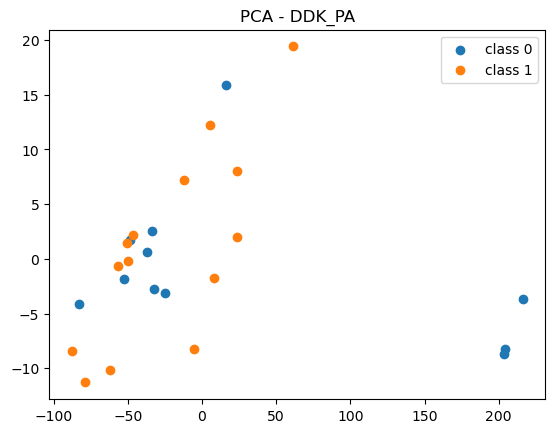

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

task = "DDK_PA"  # change to test others

X = []
y = []

for v in video_to_emb:
    if video_to_task[v] != task:
        continue

    X.append(np.mean(video_to_emb[v], axis=0))
    y.append(video_to_label[v])

X = np.array(X)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure()
for label in [0, 1]:
    idx = np.array(y) == label
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], label=f"class {label}")

plt.title(f"PCA - {task}")
plt.legend()
plt.show()

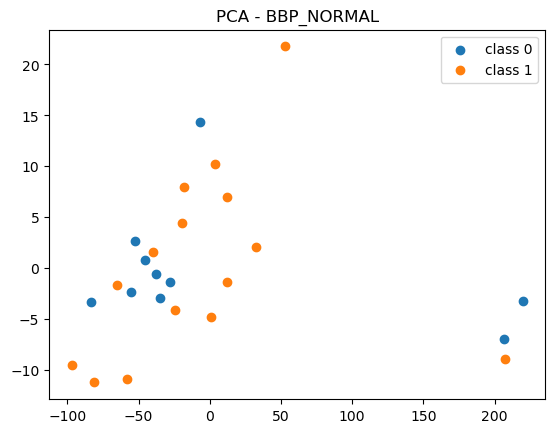

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

task = "BBP_NORMAL"  # change to test others

X = []
y = []

for v in video_to_emb:
    if video_to_task[v] != task:
        continue

    X.append(np.mean(video_to_emb[v], axis=0))
    y.append(video_to_label[v])

X = np.array(X)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure()
for label in [0, 1]:
    idx = np.array(y) == label
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], label=f"class {label}")

plt.title(f"PCA - {task}")
plt.legend()
plt.show()

In [16]:
print(set(video_to_task.values()))

{'DDK_PA', 'NSM_OPEN', 'DDK_PATAKA', 'NSM_BLOW', 'NSM_KISS', 'BBP_NORMAL', 'NSM_SPREAD'}


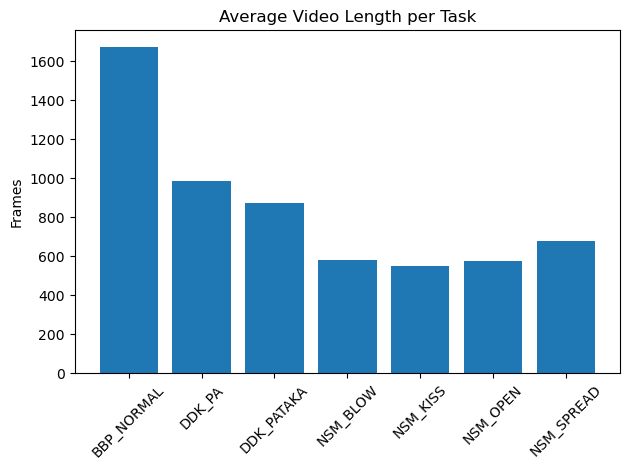

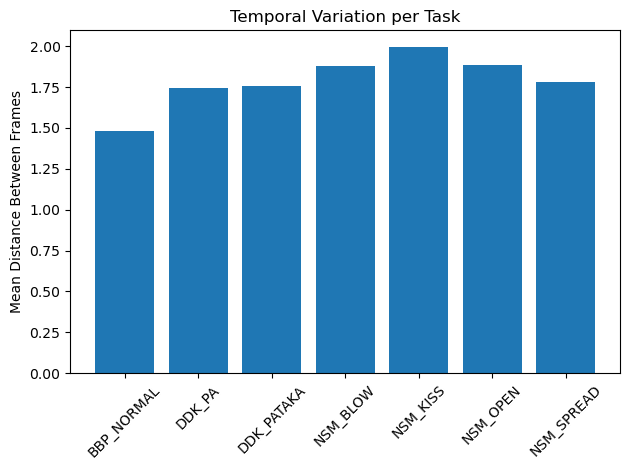

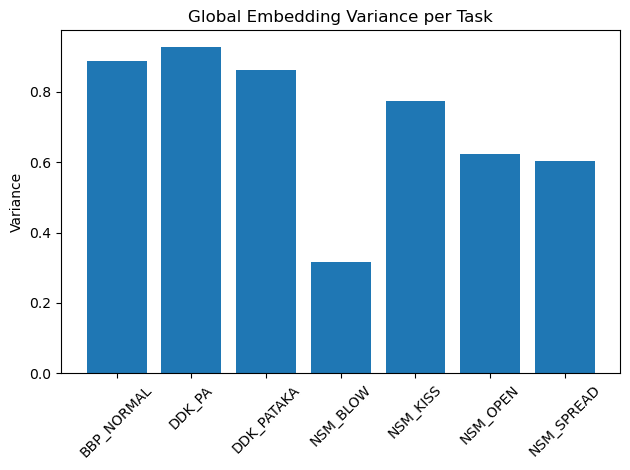

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# FUNCTIONS
# =========================
def temporal_variation(emb):
    diffs = np.linalg.norm(emb[1:] - emb[:-1], axis=1)
    return np.mean(diffs)

def global_variance(emb):
    return np.mean(np.var(emb, axis=0))

# =========================
# BUILD DATAFRAME
# =========================
rows = []

for v, emb in video_to_emb.items():
    rows.append({
        "task": video_to_task[v],
        "length": len(emb),
        "temp_var": temporal_variation(emb),
        "global_var": global_variance(emb)
    })

df_stats = pd.DataFrame(rows)

# =========================
# GROUP (MEAN ONLY)
# =========================
df_mean = df_stats.groupby("task").mean().reset_index()

# =========================
# PLOT 1 — LENGTH
# =========================
plt.figure()
plt.bar(df_mean["task"], df_mean["length"])
plt.xticks(rotation=45)
plt.title("Average Video Length per Task")
plt.ylabel("Frames")
plt.tight_layout()
plt.show()

# =========================
# PLOT 2 — TEMPORAL VAR
# =========================
plt.figure()
plt.bar(df_mean["task"], df_mean["temp_var"])
plt.xticks(rotation=45)
plt.title("Temporal Variation per Task")
plt.ylabel("Mean Distance Between Frames")
plt.tight_layout()
plt.show()

# =========================
# PLOT 3 — GLOBAL VAR
# =========================
plt.figure()
plt.bar(df_mean["task"], df_mean["global_var"])
plt.xticks(rotation=45)
plt.title("Global Embedding Variance per Task")
plt.ylabel("Variance")
plt.tight_layout()
plt.show()

Plot 1 — Length

Média do número de frames por vídeo em cada tarefa.

⸻

Plot 2 — Temporal Variation

Média da variação temporal dos embeddings (diferença entre frames consecutivos) por tarefa.

⸻

Plot 3 — Global Variance

Média da variância global dos embeddings ao longo do vídeo, por tarefa.

<Figure size 640x480 with 0 Axes>

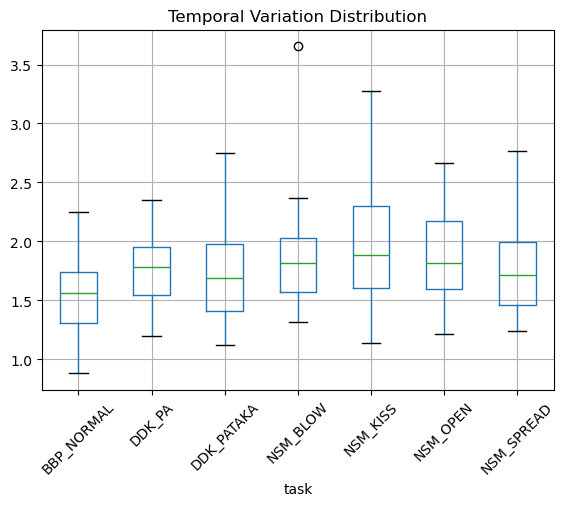

<Figure size 640x480 with 0 Axes>

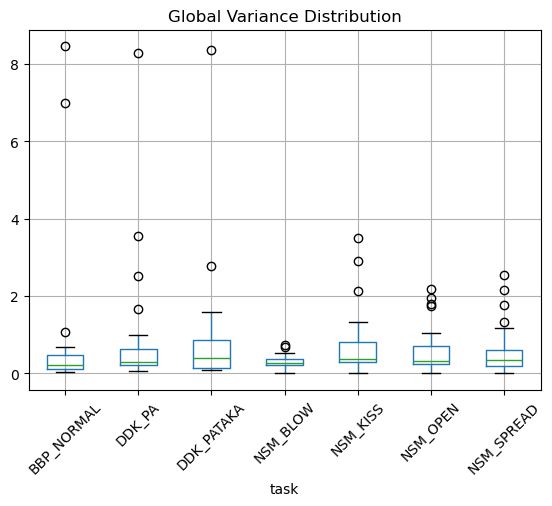

In [24]:
plt.figure()
df_stats.boxplot(column="temp_var", by="task", rot=45)
plt.title("Temporal Variation Distribution")
plt.suptitle("")
plt.show()

plt.figure()
df_stats.boxplot(column="global_var", by="task", rot=45)
plt.title("Global Variance Distribution")
plt.suptitle("")
plt.show()

Boxplot — Temporal Variation

Distribuição da variação temporal dos embeddings por tarefa.

⸻

Boxplot — Global Variance

Distribuição da variância global dos embeddings por tarefa.

Resultados Globais|

         task  total  errors  accuracy  error_rate
0  BBP_NORMAL     25       5  0.800000    0.200000
1      DDK_PA     25       2  0.920000    0.080000
2  DDK_PATAKA     25       3  0.880000    0.120000
3    NSM_BLOW     18       5  0.722222    0.277778
4    NSM_KISS     25       4  0.840000    0.160000
5    NSM_OPEN     25       4  0.840000    0.160000
6  NSM_SPREAD     25       2  0.920000    0.080000


<function matplotlib.pyplot.show(close=None, block=None)>

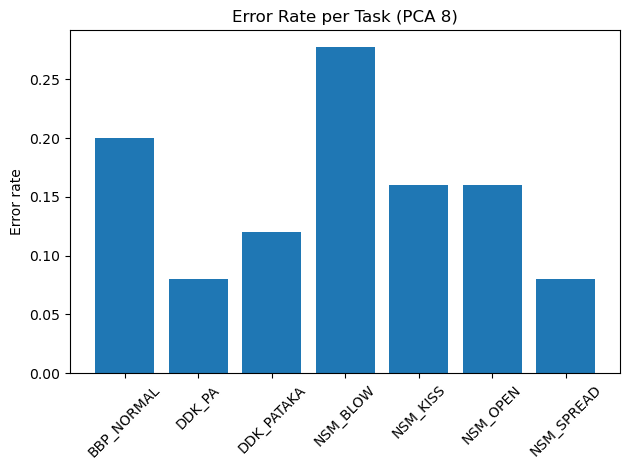

In [4]:
# error rate per task instead of raw error count
import pandas as pd
import matplotlib.pyplot as plt

df_results = pd.read_csv("/Users/beatrizrebelo/Desktop/Tese-MECD/Datasets/detailed_results_pca_8.csv")
task_summary = df_results.groupby("task").agg(
    total=("correct", "count"),
    errors=("correct", lambda x: (x == 0).sum()),
    accuracy=("correct", "mean")
).reset_index()

task_summary["error_rate"] = 1 - task_summary["accuracy"]

print(task_summary)

plt.figure()
plt.bar(task_summary["task"], task_summary["error_rate"])
plt.xticks(rotation=45)
plt.ylabel("Error rate")
plt.title(f"Error Rate per Task (PCA 8)")
plt.tight_layout()
plt.savefig(f"error_rate_per_task_pca_8.png")
plt.show

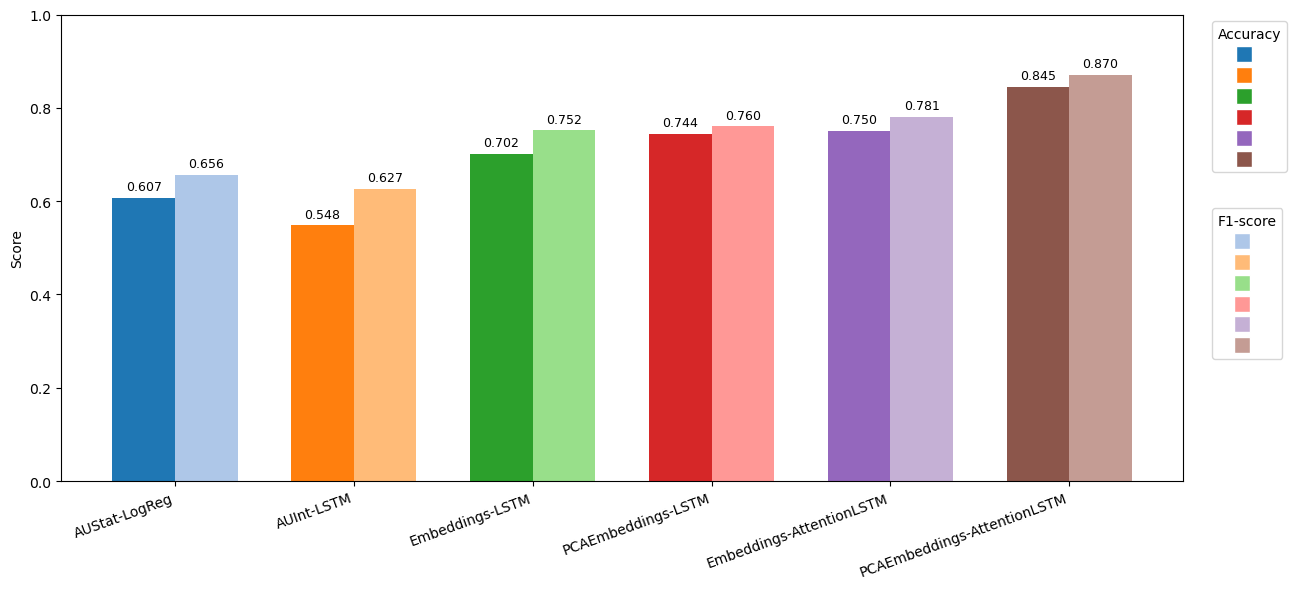

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

# ==========================================
# DATA
# ==========================================
df = pd.DataFrame({
    "Method": [
        "AUStat-LogReg",
        "AUInt-LSTM",
        "Embeddings-LSTM",
        "PCAEmbeddings-LSTM",
        "Embeddings-AttentionLSTM",
        "PCAEmbeddings-AttentionLSTM"
    ],
    "Accuracy": [0.607, 0.548, 0.702, 0.744, 0.750, 0.845],
    "F1": [0.656, 0.627, 0.752, 0.760, 0.781, 0.870]
})

# ==========================================
# PLOT
# ==========================================
x = np.arange(len(df))
width = 0.35

fig, ax = plt.subplots(figsize=(13,6))

# Dark colors = Accuracy
acc_colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b"
]

# Light colors = F1
f1_colors = [
    "#aec7e8",
    "#ffbb78",
    "#98df8a",
    "#ff9896",
    "#c5b0d5",
    "#c49c94"
]

bars1 = ax.bar(
    x - width/2,
    df["Accuracy"],
    width,
    color=acc_colors
)

bars2 = ax.bar(
    x + width/2,
    df["F1"],
    width,
    color=f1_colors
)

# ==========================================
# VALUES ON TOP
# ==========================================
for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

# ==========================================
# CUSTOM LEGEND
# ==========================================
from matplotlib.lines import Line2D

# ==========================================
# SIMPLE CUSTOM LEGEND
# ==========================================
acc_legend = [
    Line2D([0], [0], marker='s', color='w',
           markerfacecolor=c, markersize=12)
    for c in acc_colors
]

f1_legend = [
    Line2D([0], [0], marker='s', color='w',
           markerfacecolor=c, markersize=12)
    for c in f1_colors
]

# Add fake handles for labels
legend1 = ax.legend(
    acc_legend,
    [''] * len(acc_legend),
    title='Accuracy',
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

ax.add_artist(legend1)

legend2 = ax.legend(
    f1_legend,
    [''] * len(f1_legend),
    title='F1-score',
    loc='upper left',
    bbox_to_anchor=(1.02, 0.60)
)

# ==========================================
# STYLE
# ==========================================
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(df["Method"], rotation=20, ha='right')

ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

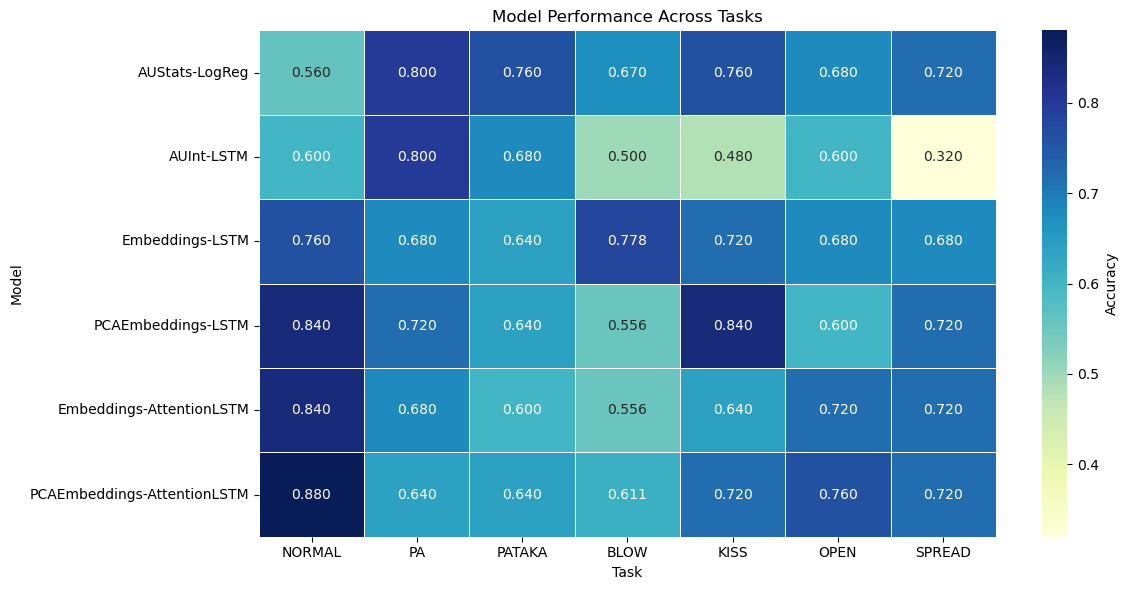

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# DATA
# ==========================================
df = pd.DataFrame({
    "NORMAL": [0.56, 0.60, 0.76, 0.84, 0.84, 0.88],
    "PA": [0.80, 0.80, 0.68, 0.72, 0.68, 0.64],
    "PATAKA": [0.76, 0.68, 0.64, 0.64, 0.60, 0.64],
    "BLOW": [0.67, 0.50, 0.778, 0.556, 0.556, 0.611],
    "KISS": [0.76, 0.48, 0.72, 0.84, 0.64, 0.72],
    "OPEN": [0.68, 0.60, 0.68, 0.60, 0.72, 0.76],
    "SPREAD": [0.72, 0.32, 0.68, 0.72, 0.72, 0.72]
},
index=[
    "AUStats-LogReg",
    "AUInt-LSTM",
    "Embeddings-LSTM",
    "PCAEmbeddings-LSTM",
    "Embeddings-AttentionLSTM",
    "PCAEmbeddings-AttentionLSTM"
])

# ==========================================
# HEATMAP
# ==========================================
plt.figure(figsize=(12,6))

ax = sns.heatmap(
    df,
    annot=True,           # write values inside cells
    fmt=".3f",            # number format
    cmap="YlGnBu",        # color palette
    linewidths=0.5,
    cbar_kws={'label': 'Accuracy'}
)

# ==========================================
# STYLE
# ==========================================
plt.title("Model Performance Across Tasks")
plt.xlabel("Task")
plt.ylabel("Model")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()